In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [ ]:
class Perceptron:
    def __init__(self, eta= 0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        #generate random numbers using the state
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float(0.)
        self.errors_ = []
        
        for _ in range(self.eta):
            #keep track of the error
            error = 0
            for xi, target in zip(X, y):
                #plot the update function
                update = self.eta * (target - self.predict(xi)) 
                
                #perform the update
                self.w_ += update * xi
                self.b_ += update

                #the error for this run
                error += int(update != 0)

            #add the error to the array of errors
            self.errors_.append(error)


    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_
    
    #predicts the ouput y for that input of x
    def predict(self, X):
        #return the decisions for the preceptron
        return np.where(self.net_input(X) >= 0.0, 1, 0)




Testing with iris dataset

In [ ]:
s = 'https://archive.ics.uci.edu/ml/'\
    'machine-learning-databases/iris/iris.data'

print("FROM URL:", s)

df = pd.read_csv(s, header= None, encoding='utf-8')
df.tail()

FROM URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


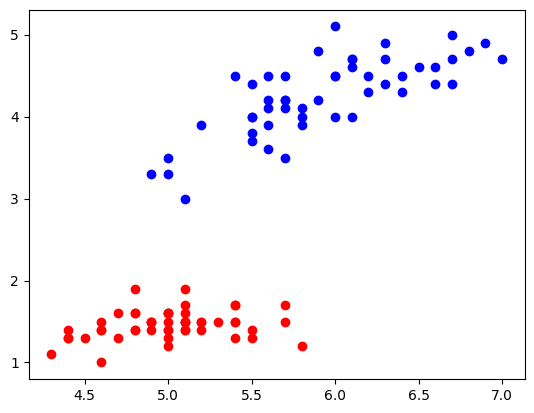

In [ ]:
#get the types of targets
df[4].unique()
#get the targets for the first 100 examples
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', 0, 1)

#get the features (sepal length and petal length)
X = df.iloc[0:100, [0,2]].values

plt.scatter(X[:50, 0],X[:50, 1],color='red', marker='o', label = 'Setosa')
plt.scatter(X[50:100,0],X[50:100, 1], color='blue', marker='o', label = 'Setosa')


plt.xlabel("Sepal length [cm]")
plt.ylabel("pedal length [cm]")
plt.legend(loc = 'upper left')
plt.show()